In [1]:

!pip install keras tensorflow


In [2]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


In [3]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [4]:
def load_data(data_dir, img_size=(28, 28)):
    images = []
    labels = []

    for label in os.listdir(data_dir):  # 0-9 folders
        label_path = os.path.join(data_dir, label)

        if os.path.isdir(label_path):
            for img_file in os.listdir(label_path):
                img_path = os.path.join(label_path, img_file)

                # Load image
                img = Image.open(img_path).convert('L')  # grayscale
                img = img.resize(img_size)

                img_array = np.array(img)
                images.append(img_array)
                labels.append(int(label))

    images = np.array(images)
    labels = np.array(labels)

    return images, labels

In [5]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AIML/Copy of devnagari digit.zip"
extract_path = "data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")


Extraction completed!


In [6]:
base_path = "/content/data/DevanagariHandwrittenDigitDataset"

train_dir = os.path.join(base_path, "Train")
test_dir = os.path.join(base_path, "Test")

In [7]:
from PIL import Image
import numpy as np

def load_data(data_dir, img_size=(28, 28)):
    images = []
    labels = []

    for folder in os.listdir(data_dir):
        folder_path = os.path.join(data_dir, folder)

        if os.path.isdir(folder_path):
            # Extract label number from folder name
            label = int(folder.split('_')[-1])

            for img_file in os.listdir(folder_path):
                img_path = os.path.join(folder_path, img_file)

                try:
                    img = Image.open(img_path).convert('L')  # grayscale
                    img = img.resize(img_size)

                    img_array = np.array(img)
                    images.append(img_array)
                    labels.append(label)

                except Exception as e:
                    print(f"Error loading {img_path}: {e}")

    return np.array(images), np.array(labels)

In [8]:

X_train, y_train = load_data(train_dir)
X_test, y_test = load_data(test_dir)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (17000, 28, 28)
Test shape: (3000, 28, 28)


In [9]:
from tensorflow.keras.utils import to_categorical

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

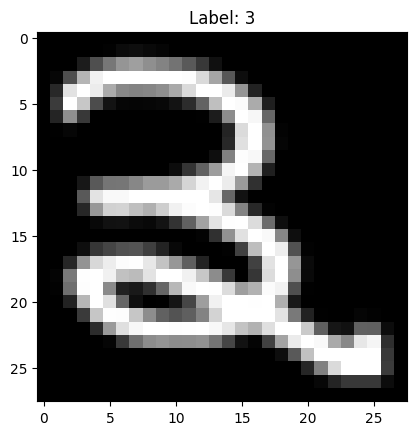

In [10]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {np.argmax(y_train[0])}")
plt.show()

In [11]:
model = Sequential([
    Flatten(input_shape=(28, 28)),   # convert 2D -> 1D

    Dense(64, activation='sigmoid'),
    Dense(128, activation='sigmoid'),
    Dense(256, activation='sigmoid'),

    Dense(10, activation='softmax')  # output layer
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [19]:
model = Sequential([
    Flatten(input_shape=(28, 28)),   # convert 2D -> 1D

    Dense(64, activation='sigmoid'),
    Dense(128, activation='sigmoid'),
    Dense(256, activation='sigmoid'),

    Dense(10, activation='softmax')  # output layer
])

In [20]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint("best_model.h5", save_best_only=True)
]

history = model.fit(
    X_train, y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/20
105/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2723 - loss: 2.0385

107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4656 - loss: 1.6953 - val_accuracy: 0.0000e+00 - val_loss: 6.9458
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8391 - loss: 0.5451 - val_accuracy: 0.0000e+00 - val_loss: 7.9187
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9212 - loss: 0.2659 - val_accuracy: 0.0000e+00 - val_loss: 8.8613
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9510 - loss: 0.1743 - val_accuracy: 0.0000e+00 - val_loss: 9.3070
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9616 - loss: 0.1314 - val_accuracy: 0.0000e+00 - val_loss: 9.7220
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9708 - loss: 0.1058 - val_accuracy: 0.0000e+00 - val_loss: 9.9943


In [22]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6253 - loss: 2.1361
Test Accuracy: 0.625333309173584
Test Loss: 2.1361162662506104


In [23]:
# Save
model.save("devnagari_model.h5")

# Load
loaded_model = load_model("devnagari_model.h5")

# Re-evaluate
loss, acc = loaded_model.evaluate(X_test, y_test)
print("Loaded Model Accuracy:", acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6253 - loss: 2.1361
Loaded Model Accuracy: 0.625333309173584


In [24]:
predictions = loaded_model.predict(X_test)

# Convert probabilities -> labels
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

# Show sample predictions
for i in range(5):
    print(f"Predicted: {predicted_labels[i]}, Actual: {true_labels[i]}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Predicted: 3, Actual: 3
Predicted: 3, Actual: 3
Predicted: 7, Actual: 3
Predicted: 3, Actual: 3
Predicted: 5, Actual: 3
